In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from google.colab import files

# Upload the storm data file to Google Colab
uploaded = files.upload()

# Load the data
data = pd.read_csv('main - main.csv')


Saving main - main.csv to main - main.csv


/usr/local/lib/python3.8/dist-packages/pandas/core/frame.py:3678: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[col] = igetitem(value, i)
/usr/local/lib/python3.8/dist-packages/pandas/core/frame.py:3678: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[col] = igetitem(value, i)


Epoch 1/100
63/63 [==============================] - 2s 4ms/step - loss: 0.1465
Epoch 2/100
63/63 [==============================] - 0s 3ms/step - loss: 0.0127
Epoch 3/100
63/63 [==============================] - 0s 3ms/step - loss: 0.0074
Epoch 4/100
63/63 [==============================] - 0s 4ms/step - loss: 0.0061
Epoch 5/100
63/63 [==============================] - 0s 4ms/step - loss: 0.0058
Epoch 6/100
63/63 [==============================] - 0s 3ms/step - loss: 0.0057
Epoch 7/100
63/63 [==============================] - 0s 4ms/step - loss: 0.0055
Epoch 8/100
63/63 [==============================] - 0s 4ms/step - loss: 0.0054
Epoch 9/100
63/63 [==============================] - 0s 4ms/step - loss: 0.0053
Epoch 10/100
63/63 [==============================] - 0s 3ms/step - loss: 0.0051
Epoch 11/100
63/63 [==============================] - 0s 3ms/step - loss: 0.0050
Epoch 12/100
63/63 [==============================] - 0s 4ms/step - loss: 0.0050
Epoch 13/100
63/63 [=================

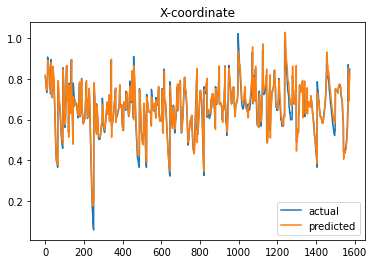

Actual values: [0.81055901 0.80124224 0.78881988 ... 0.78571429 0.81677019 0.84782609]
Predicted values: [0.81853306 0.8100828  0.8018685  ... 0.77433497 0.79038    0.81925935]


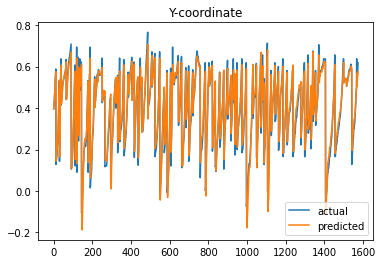

In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load the data
data = pd.read_csv('main - main.csv')

# Split the data into training and testing sets
train_data = data[data['Storm Number'] <= 100]
test_data = data[data['Storm Number'] > 100]

# Select the input features and output feature
input_features = ['x', 'y', 'Max Wind Speed (kt)']
output_features = ['x', 'y']

# Normalize the input data using MinMaxScaler
scaler = MinMaxScaler()
train_data[input_features] = scaler.fit_transform(train_data[input_features])
test_data[input_features] = scaler.transform(test_data[input_features])

# Create the input and output sequences for the training and testing data
def create_sequences(data):
    X = []
    y = []
    for i in range(len(data)-2):
        X.append(data[i:i+2, :3])
        y.append(data[i+2, :2])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data[input_features + output_features].values)
X_test, y_test = create_sequences(test_data[input_features + output_features].values)

# Create the model
model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(2, 3)))
model.add(Dense(2))

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=32)

# Make predictions on the testing data
y_pred = model.predict(X_test)



# Plot the predicted and actual outputs for the x-coordinate
plt.plot(y_test[:,0], label='actual')
plt.plot(y_pred[:,0], label='predicted')
plt.title('X-coordinate')
plt.legend()
plt.show()
print('Actual values:', y_test[:,0])
print('Predicted values:', y_pred[:,0])

# Plot the predicted and actual outputs for the y-coordinate
plt.plot(y_test[:,1], label='actual')
plt.plot(y_pred[:,1], label='predicted')
plt.title('Y-coordinate')
plt.legend()
plt.show()
print('Actual values:', y_test[:,1])
print('Predicted values:', y_pred[:,1])



# Plot the predicted and actual storm tracks on a world map
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

ax.plot(y_test[:,0], y_test[:,1], label='Actual', color='red', linewidth=2, transform=ccrs.PlateCarree())
ax.plot(y_pred[:,0], y_pred[:,1], label='Predicted', color='blue', linewidth=2, transform=ccrs.PlateCarree())

ax.legend(loc='upper left')

plt.show()


World Map

In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Load the data
data = pd.read_csv('main - main.csv')

# Split the data into training and testing sets
train_data = data[data['Storm Number'] <= 100]
test_data = data[data['Storm Number'] > 100]

# Select the input features and output feature
input_features = ['x', 'y', 'Max Wind Speed (kt)']
output_features = ['x', 'y']

# Normalize the input data using MinMaxScaler
scaler = MinMaxScaler()
train_data[input_features] = scaler.fit_transform(train_data[input_features])
test_data[input_features] = scaler.transform(test_data[input_features])

# Create the input and output sequences for the training and testing data
def create_sequences(data):
    X = []
    y = []
    for i in range(len(data)-2):
        X.append(data[i:i+2, :3])
        y.append(data[i+2, :2])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data[input_features + output_features].values)
X_test, y_test = create_sequences(test_data[input_features + output_features].values)

# Create the model
model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(2, 3)))
model.add(Dense(2))

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=32)

# Make predictions on the testing data
y_pred = model.predict(X_test)




# Plot the predicted and actual storm tracks on a world map
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

ax.plot(y_test[:,0], y_test[:,1], label='Actual', color='red', linewidth=2, transform=ccrs.PlateCarree())
ax.plot(y_pred[:,0], y_pred[:,1], label='Predicted', color='blue', linewidth=2, transform=ccrs.PlateCarree())

ax.legend(loc='upper left')

plt.show()


Epoch 1/100


/usr/local/lib/python3.8/dist-packages/pandas/core/frame.py:3678: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[col] = igetitem(value, i)
/usr/local/lib/python3.8/dist-packages/pandas/core/frame.py:3678: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[col] = igetitem(value, i)


63/63 [==============================] - 2s 4ms/step - loss: 0.1017
Epoch 2/100
63/63 [==============================] - 0s 3ms/step - loss: 0.0124
Epoch 3/100
63/63 [==============================] - 0s 4ms/step - loss: 0.0072
Epoch 4/100
63/63 [==============================] - 0s 4ms/step - loss: 0.0061
Epoch 5/100
63/63 [==============================] - 0s 3ms/step - loss: 0.0059
Epoch 6/100
63/63 [==============================] - 0s 4ms/step - loss: 0.0059
Epoch 7/100
63/63 [==============================] - 0s 4ms/step - loss: 0.0057
Epoch 8/100
63/63 [==============================] - 0s 4ms/step - loss: 0.0055
Epoch 9/100
63/63 [==============================] - 0s 4ms/step - loss: 0.0054
Epoch 10/100
63/63 [==============================] - 0s 4ms/step - loss: 0.0052
Epoch 11/100
63/63 [==============================] - 0s 3ms/step - loss: 0.0051
Epoch 12/100
63/63 [==============================] - 0s 4ms/step - loss: 0.0050
Epoch 13/100
63/63 [=============================